<a href="https://colab.research.google.com/github/bihjane/Data-science-and-AI-K-12-teaching-tools/blob/main/Copy_of_LR_Multiple_Features_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple Linear Regression: Square Footage, Bedrooms, Bathrooms, and House Type
### Loudoun County, VA Housing Data — pandas, matplotlib, scikit-learn

**Purpose of this notebook:** This is the companion to `LR_SquareFeet_Only.ipynb`.
There we predicted price from square footage alone. Here we extend the model
with three more predictors:

- **Square Feet** (numeric)
- **Bedrooms** (numeric)
- **Bathrooms** (numeric)
- **House type** (categorical: Condo / Townhome / Detached)

This introduces two ideas that don't come up in a single-feature model:

1. **Feature scaling across multiple numeric variables on different scales**
   (square feet ranges in the thousands; bedrooms range from 2-6).
2. **Encoding a categorical variable as numbers** a linear model can use
   (one-hot encoding), and the "dummy variable trap" that comes with it.

**A note on the data, up front:** this dataset has only **47 rows**. That is
fine for demonstrating the mechanics of multiple regression, but far too small
to trust as a real market model — with four predictors and ~37 training rows,
we are asking a lot from very little data. Say this out loud to students:
adding predictors to a small dataset does not automatically make a model
better, and can make it *less* reliable by increasing the risk of overfitting.


## 1. About the dataset

Same source file as the first notebook (`loudoun_housing.csv`, pulled from
Google Drive):

| Column | Description | Type as stored in the CSV |
|---|---|---|
| `Price in 1,000's` | Listing price, already expressed in units of \$1,000 (e.g. `$337.50` means \$337,500) | text, formatted like currency |
| `Bedrooms` | Number of bedrooms | integer |
| `Bathrooms` | Number of bathrooms (half-baths count as `.5`) | float |
| `Square Feet` | Finished square footage | integer |
| `House type` | `Condo`, `Townhome`, or `Detached` | text |
| `Address`, `City` | Location fields — not used as model features | text |

As in the first notebook: the price column's header already tells us the
units, so we strip the `$` formatting and convert to a float — we do **not**
divide by 1,000 again.


## 2. Import libraries

Same core stack as the first notebook, plus two additions for handling mixed
numeric/categorical data cleanly:

- **`ColumnTransformer`** — applies different preprocessing to different
  columns (scale the numeric ones, one-hot-encode the categorical one) in a
  single, organized step.
- **`OneHotEncoder`** — converts a categorical column into multiple 0/1
  indicator columns a linear model can actually use.
- **`Pipeline`** — chains preprocessing and the model together so both happen
  in the correct order, and so the exact same preprocessing is guaranteed to
  be reapplied to new/test data.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100


## 3. Load the data

The dataset lives in Google Drive, so we download it directly with
[`gdown`](https://github.com/wkentaro/gdown) rather than requiring a manual
file upload each time the notebook runs. `gdown` needs the file's Google
Drive **file ID**, which is the long string of characters in the share link
between `/d/` and `/view`:

`https://drive.google.com/file/d/`**`1rgQCA6x7cN-HK0OrcfB6sgtfhxlNrg_2`**`/view?usp=sharing`

The file must be shared as "Anyone with the link can view" for this to work
without authentication — if you get a permissions error instead of a CSV,
that's the first thing to check.


In [ ]:
# gdown ships preinstalled in Colab; the -q install here is just a safety net
# for local Jupyter environments where it might be missing.

import gdown

FILE_ID = "1rgQCA6x7cN-HK0OrcfB6sgtfhxlNrg_2"
FILENAME = "loudoun_housing.csv"

gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", FILENAME, quiet=False)

raw_df = pd.read_csv(FILENAME)
raw_df.head()


Downloading...
From: https://drive.google.com/uc?id=1rgQCA6x7cN-HK0OrcfB6sgtfhxlNrg_2
To: /content/loudoun_housing.csv
100%|██████████| 2.40k/2.40k [00:00<00:00, 5.62MB/s]


,Price_thousands,Bedrooms,Bathrooms,Square Feet,House type,Address,City
0,338,3,2,1534,Condo,19375 cypress ridge Terr,Leesburg
1,740,4,5,4472,Detached,24970 greengage PL,aldi
2,817,4,5,6824,Detached,22770 brookshade dr,ashburn
3,353,3,3,2060,Townhome,6 Paxton Ct,sterling
4,358,3,3,1720,Townhome,21807 learleaf cir,sterling


## 4. Clean the data

Parse the price column as before, and keep only the columns we need
(`Square Feet`, `Bedrooms`, `Bathrooms`, `House type`, price). This version
of the file already has `House type` capitalization consistent, so no text
normalization step is needed there — but we still print its value counts as
a quick sanity check.


In [ ]:
df = raw_df.copy()

df = df[["Square Feet", "Bedrooms", "Bathrooms", "House type", "Price_thousands"]]

print(df["House type"].value_counts())
print()
df.describe()


House type
Detached    28
Townhome    15
Condo        4
Name: count, dtype: int64



,Square Feet,Bedrooms,Bathrooms,Price_thousands
count,47.000000,47.000000,47.000000,47.000000
mean,3327.468085,3.723404,3.893617,574.638298
std,1545.467297,0.877301,1.026477,181.883076
min,853.000000,2.000000,2.000000,278.000000
25%,2231.000000,3.000000,3.000000,424.500000
50%,3268.000000,4.000000,4.000000,604.000000
75%,4484.500000,4.000000,5.000000,699.500000
max,6824.000000,6.000000,6.000000,1000.000000


## 5. Explore relationships before modeling

### 5a. Correlation heatmap (numeric features only)
Correlation tells us, roughly, how strongly each numeric feature moves
together with price (and with each other). Multiple predictors that are
highly correlated *with each other* (not shown as a problem here, but worth
naming) is called multicollinearity, and it can make individual coefficients
unstable/hard to interpret even when overall predictions are fine.


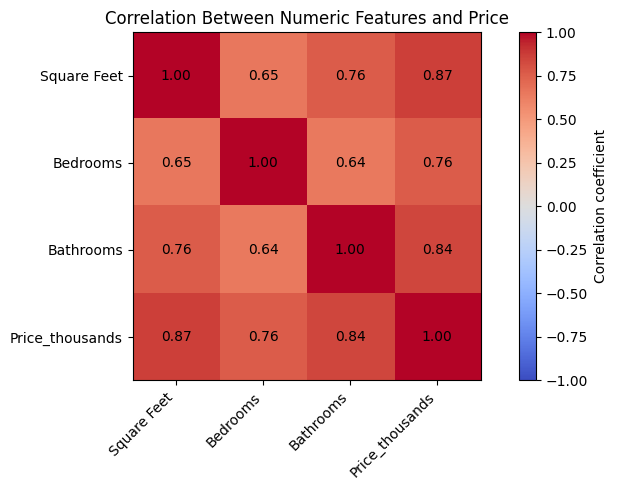

In [ ]:
numeric_cols = ["Square Feet", "Bedrooms", "Bathrooms", "Price_thousands"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots()
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)

# Print the correlation value inside each cell
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, label="Correlation coefficient")
plt.title("Correlation Between Numeric Features and Price")
plt.tight_layout()
plt.show()


### 5b. Price by house type
A boxplot shows how price varies across the three categories directly — this
is the relationship `House type` is meant to capture in the model.


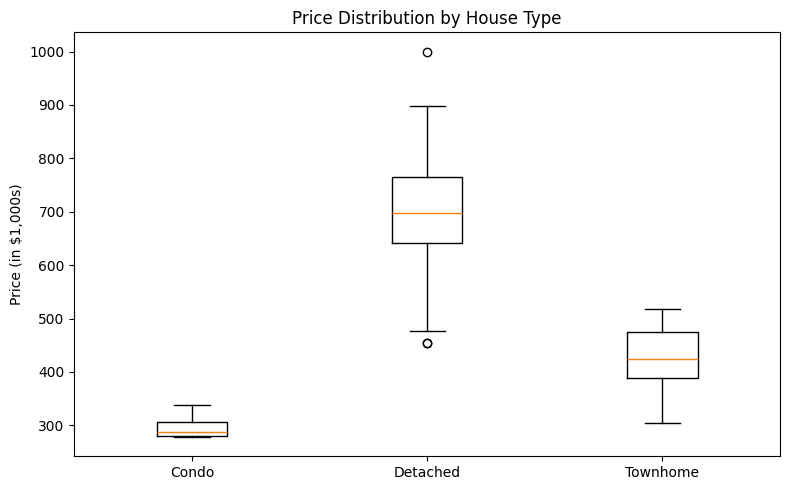

In [ ]:
house_types = df["House type"].unique()
price_by_type = [df.loc[df["House type"] == t, "Price_thousands"] for t in house_types]

plt.boxplot(price_by_type, tick_labels=house_types)
plt.ylabel("Price (in $1,000s)")
plt.title("Price Distribution by House Type")
plt.tight_layout()
plt.show()


## 6. Split into training and test sets

Same reasoning as the first notebook: fit only on the training set, evaluate
only on the held-out test set. Same 80/20 split and `random_state=42` for
reproducibility and easy comparison against the single-feature model.


In [ ]:
feature_cols = ["Square Feet", "Bedrooms", "Bathrooms", "House type"]
X = df[feature_cols]
y = df["Price_thousands"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows:     {len(X_test)}")


Training rows: 37
Test rows:     10


## 7. Build a preprocessing pipeline: scale numeric features, encode the categorical feature

Two different transformations are needed on two different sets of columns:

- **Numeric columns** (`Square Feet`, `Bedrooms`, `Bathrooms`) → `StandardScaler`,
  exactly as in the first notebook. This matters more here than it did with a
  single feature: square footage (thousands) and bedroom count (single digits)
  are on wildly different scales, and without scaling, the raw coefficients
  would not be comparable to each other at all.
- **Categorical column** (`House type`) → `OneHotEncoder`, which turns the
  3-category column into indicator (0/1) columns. We pass `drop="first"` to
  drop one category as the **reference category** — this avoids the "dummy
  variable trap," where keeping all *k* indicator columns for a *k*-category
  variable makes them perfectly predictable from one another and breaks the
  regression's assumptions. With `drop="first"`, `Condo` (alphabetically
  first) becomes the reference; the coefficients on the remaining categories
  are interpreted as "difference vs. Condo," holding other features constant.

`ColumnTransformer` applies each transformation to the right columns; wrapping
everything in a `Pipeline` means calling `.fit()` once runs both preprocessing
steps and the model fit together, in the correct order, and guarantees the
exact same preprocessing is applied when we later call `.predict()` on new
data.


In [ ]:
numeric_features = ["Square Feet", "Bedrooms", "Bathrooms"]
categorical_features = ["House type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features),
    ]
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", LinearRegression()),
])

pipeline.fit(X_train, y_train)
print("Pipeline fit complete.")


Pipeline fit complete.


## 8. Print and interpret the weights

We pull the fitted `LinearRegression` step out of the pipeline to read its
`.coef_`, and use the preprocessor's `get_feature_names_out()` to recover
which coefficient belongs to which feature (including the one-hot-encoded
categories). Because the numeric features are scaled, these coefficients
are directly comparable to each other in magnitude — a genuinely useful
property when discussing "which feature matters most" with students, with the
caveat that "matters most" here means "most influential on price *within the
range of this small dataset*," not a universal truth about housing markets.


In [ ]:
encoded_feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
weights = pipeline.named_steps["regressor"].coef_
intercept = pipeline.named_steps["regressor"].intercept_

print("Feature weights (scaled/encoded units):")
for name, weight in zip(encoded_feature_names, weights):
    print(f"  {name:30s} {weight:>10.4f}")
print()
print(f"Intercept: {intercept:.4f}")
print()
print("Note: 'cat__House type_Detached' and 'cat__House type_Townhome' are")
print("read relative to the reference category, Condo (dropped by OneHotEncoder).")


Feature weights (scaled/encoded units):
  num__Square Feet                  51.7128
  num__Bedrooms                     32.4751
  num__Bathrooms                    71.8061
  cat__House type_Detached          84.4474
  cat__House type_Townhome         -12.1915

Intercept: 531.9088

Note: 'cat__House type_Detached' and 'cat__House type_Townhome' are
read relative to the reference category, Condo (dropped by OneHotEncoder).


### 8a. Visualize the weights

Because every numeric feature was scaled the same way, and the categorical
weights represent a comparable "shift from baseline," it's reasonable to plot
all the coefficients on one bar chart to compare their relative influence.


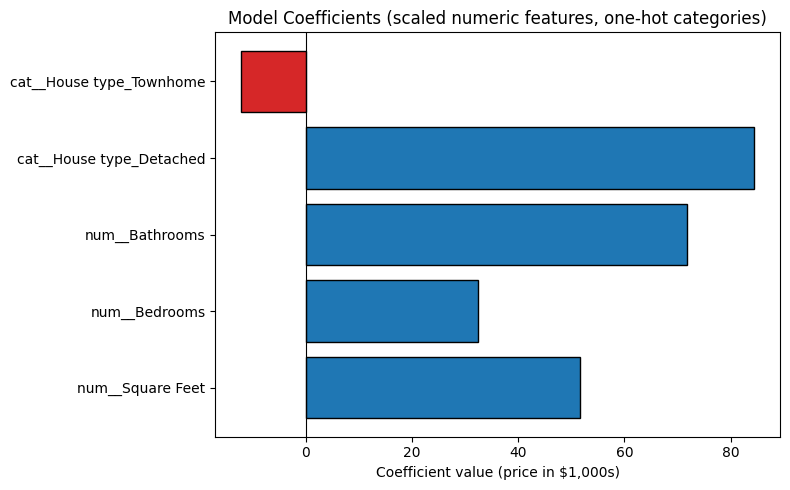

In [ ]:
fig, ax = plt.subplots()
colors = ["tab:red" if w < 0 else "tab:blue" for w in weights]
ax.barh(encoded_feature_names, weights, color=colors, edgecolor="k")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient value (price in $1,000s)")
ax.set_title("Model Coefficients (scaled numeric features, one-hot categories)")
plt.tight_layout()
plt.show()


## 9. Evaluate on the test set

Same three metrics as the first notebook — this time we can directly compare
against the single-feature model to see whether the extra predictors actually
helped, which is exactly the comparison a PD session should walk through.


In [ ]:
y_pred = pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2:  {r2:.3f}")
print(f"MAE:  {mae:.2f}  (thousand dollars)")
print(f"RMSE: {rmse:.2f}  (thousand dollars)")
print()
print("Compare these to the single-feature (Square Feet only) model's metrics")
print("from LR_SquareFeet_Only.ipynb. With only ~9 test rows, don't over-read")
print("small differences — re-run with a different random_state and see how")
print("much these numbers move.")


R^2:  0.948
MAE:  29.12  (thousand dollars)
RMSE: 35.64  (thousand dollars)

Compare these to the single-feature (Square Feet only) model's metrics
from LR_SquareFeet_Only.ipynb. With only ~9 test rows, don't over-read
small differences — re-run with a different random_state and see how
much these numbers move.


## 10. Line plot: square footage vs. price

With four predictors, there's no single 2-D line that represents "the model."
Instead we show two useful views side by side, both standard in applied
regression work:

- **Left:** the raw data, colored by house type, so the square-footage/price
  relationship is visible alongside the categorical effect.
- **Right:** a **partial dependence-style line** — we hold `Bedrooms`,
  `Bathrooms`, and `House type` fixed at typical (mean/most common) values,
  and vary only `Square Feet`, to show what the model predicts *for square
  footage specifically*, all else held equal. This is the standard way to get
  a single 2-D "line plot" out of a multi-feature linear model.


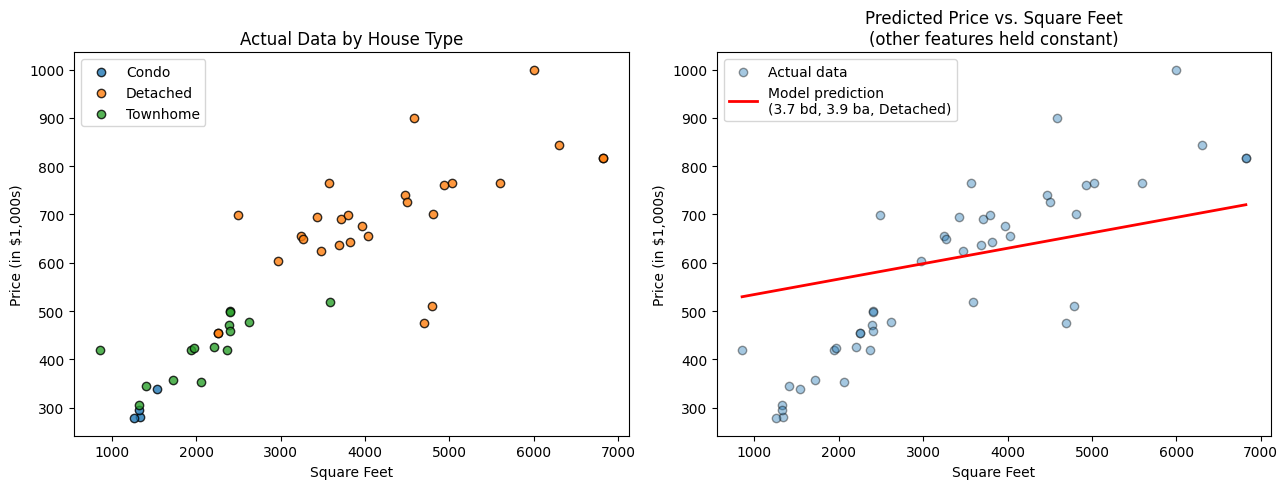

In [ ]:
# Typical values to hold constant while we vary Square Feet
typical_bedrooms = df["Bedrooms"].mean()
typical_bathrooms = df["Bathrooms"].mean()
typical_house_type = df["House type"].mode()[0]

sqft_range = np.linspace(df["Square Feet"].min(), df["Square Feet"].max(), 200)

partial_dependence_df = pd.DataFrame({
    "Square Feet": sqft_range,
    "Bedrooms": typical_bedrooms,
    "Bathrooms": typical_bathrooms,
    "House type": typical_house_type,
})

partial_predictions = pipeline.predict(partial_dependence_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: raw data colored by house type
for t in df["House type"].unique():
    subset = df[df["House type"] == t]
    axes[0].scatter(subset["Square Feet"], subset["Price_thousands"], label=t, alpha=0.8, edgecolor="k")
axes[0].set_xlabel("Square Feet")
axes[0].set_ylabel("Price (in $1,000s)")
axes[0].set_title("Actual Data by House Type")
axes[0].legend()

# Right plot: model's predicted line for Square Feet, other features held at typical values
axes[1].scatter(df["Square Feet"], df["Price_thousands"], alpha=0.4, edgecolor="k", label="Actual data")
axes[1].plot(sqft_range, partial_predictions, color="red", linewidth=2,
             label=f"Model prediction\n({typical_bedrooms:.1f} bd, {typical_bathrooms:.1f} ba, {typical_house_type})")
axes[1].set_xlabel("Square Feet")
axes[1].set_ylabel("Price (in $1,000s)")
axes[1].set_title("Predicted Price vs. Square Feet\n(other features held constant)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Other visualizations worth showing students

### 11a. Predicted vs. actual price


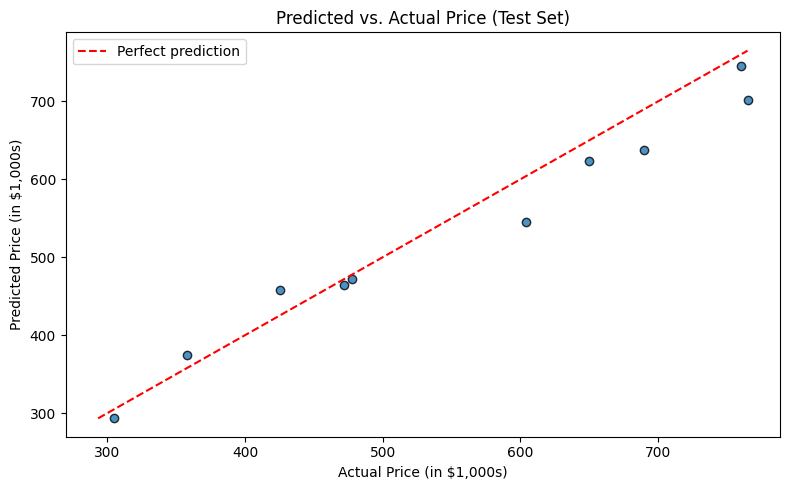

In [ ]:
plt.scatter(y_test, y_pred, edgecolor="k", alpha=0.8)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Price (in $1,000s)")
plt.ylabel("Predicted Price (in $1,000s)")
plt.title("Predicted vs. Actual Price (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()


### 11b. Residual plot
Same purpose as in the first notebook: look for a pattern (there shouldn't be
one) as evidence for or against the linear model's assumptions holding up.


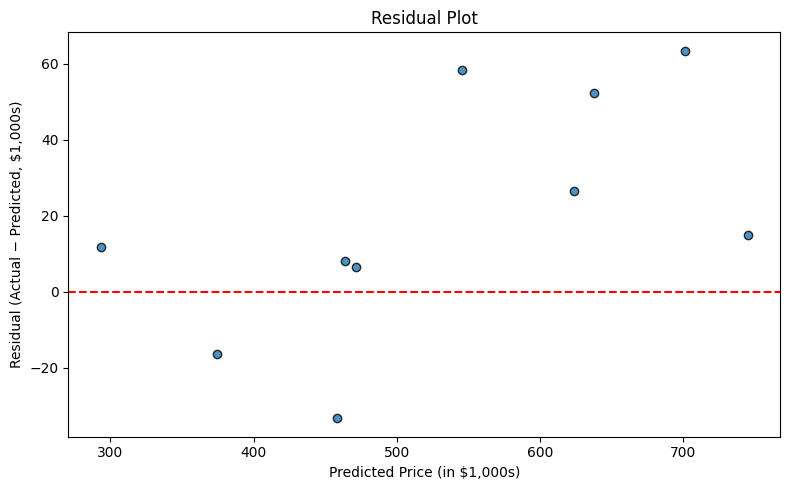

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, edgecolor="k", alpha=0.8)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price (in $1,000s)")
plt.ylabel("Residual (Actual − Predicted, $1,000s)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()


### 11c. Pairwise scatter matrix
A quick way to see every numeric-feature-to-price relationship at once,
without writing a separate scatter plot for each pair.


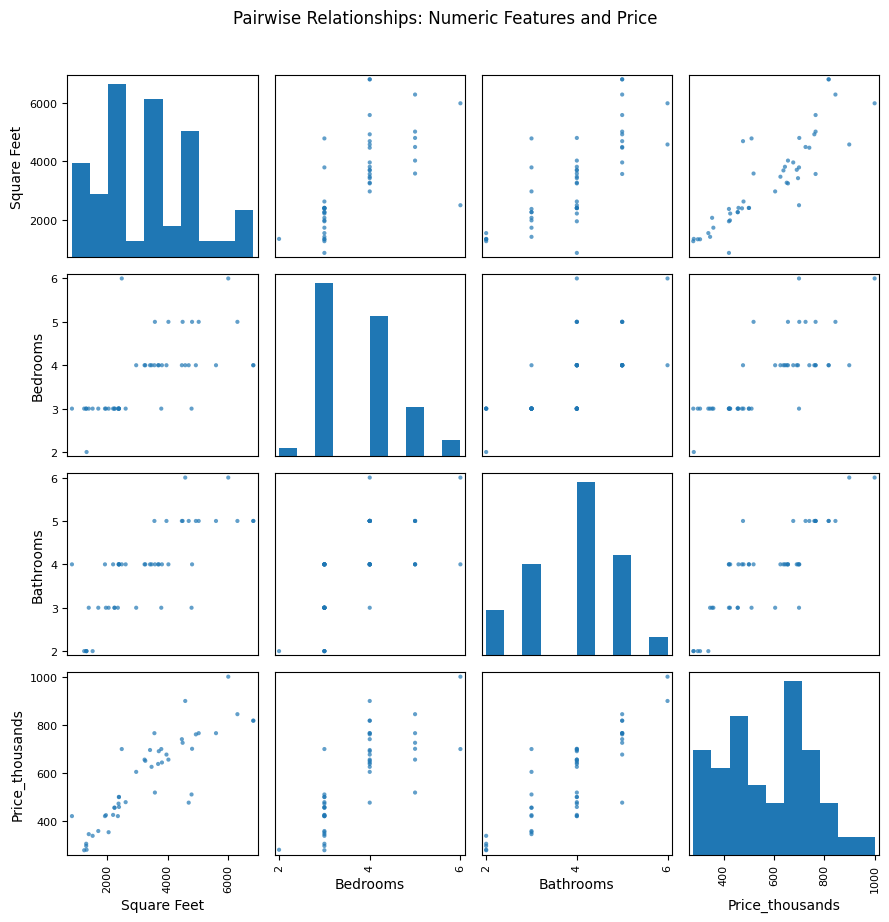

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(df[["Square Feet", "Bedrooms", "Bathrooms", "Price_thousands"]],
               figsize=(9, 9), diagonal="hist", alpha=0.7)
plt.suptitle("Pairwise Relationships: Numeric Features and Price", y=1.02)
plt.tight_layout()
plt.show()


## 12. Discussion prompts for a PD session

- Compare this model's R²/MAE/RMSE to the single-feature model's. Did adding
  bedrooms, bathrooms, and house type actually improve test-set performance,
  or mostly add noise given how little data we have?
- Look at the coefficient bar chart: which feature has the largest magnitude?
  Does that match your intuition about the Loudoun County housing market — and
  where might that intuition be wrong given only 47 data points?
- Why did we drop one category (`Condo`) from the one-hot encoding instead of
  keeping all three? What breaks if you don't?
- What would change about the "line plot" if you held house type at
  `Detached` instead of the most common category? Try changing
  `typical_house_type` and re-running that cell.
- This dataset conflates city/neighborhood effects (Leesburg vs. Ashburn vs.
  Sterling, etc.) with house type and size. If you had access to `City`, how
  might you incorporate it, and what new categorical-encoding issues would
  that raise (more categories, smaller groups per category, etc.)?
